## FIDSON STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

fidson=pd.read_csv('../stock_data/fidson.csv') ## so it can be small letter. This is cool.
fidson=fidson.drop(columns=['high_price','low_price'])
fidson.rename(columns={'trade_date':'date'},inplace=True)
fidson['date']=pd.to_datetime(fidson['date'])
fidson['month']=fidson['date'].dt.month
fidson['quarter']=fidson['date'].dt.quarter
fidson['year']=fidson['date'].dt.year

fidson

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42832,FIDSON,2017-01-03,1.33,1.33,116883,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43392,FIDSON,2017-01-04,1.33,1.33,21100,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43502,FIDSON,2017-01-05,1.33,1.33,25005,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43612,FIDSON,2017-01-06,1.33,1.33,4655,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43702,FIDSON,2017-01-09,1.33,1.33,34000,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298061,FIDSON,2026-07-13,102.75,102.75,1054009,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298499,FIDSON,2026-07-14,102.75,102.75,323324,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298937,FIDSON,2026-07-15,102.75,102.75,491108,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299375,FIDSON,2026-07-16,102.75,102.75,1627554,2026-07-16T15:10:03.113936+00:00,7,3,2026


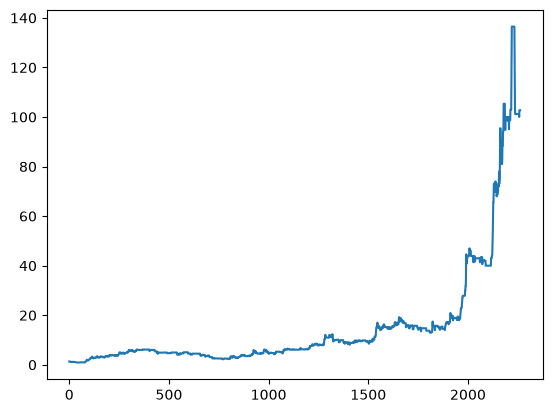

In [2]:
import matplotlib.pyplot as plt

plt.plot(fidson['close_price'])
plt.show()

In [3]:
fidson_end_month_df = (
    fidson
    .sort_values("date")
    .groupby(fidson["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

fidson_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45402,FIDSON,2017-01-31,1.14,1.14,25020,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47224,FIDSON,2017-02-28,0.91,0.91,20000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49340,FIDSON,2017-03-31,0.99,0.99,276941,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51167,FIDSON,2017-04-28,1.10,1.10,260888,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53090,FIDSON,2017-05-31,2.28,2.28,1805800,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35299,FIDSON,2026-03-31,100.00,100.00,1089202,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281125,FIDSON,2026-04-30,98.70,98.70,611335,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284191,FIDSON,2026-05-29,136.50,136.50,435157,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294119,FIDSON,2026-06-30,101.20,101.20,291575,2026-06-30T15:10:03.08168+00:00,6,2,2026


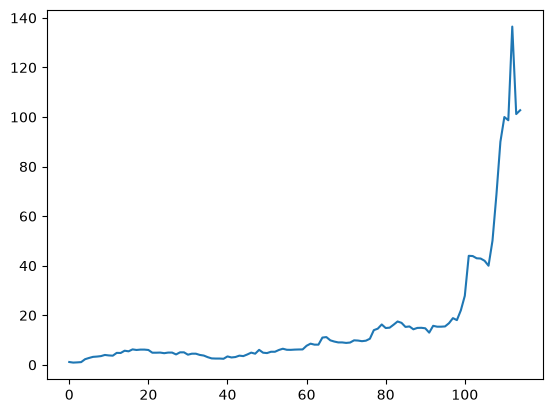

In [4]:
plt.plot(fidson_end_month_df['close_price'])
plt.show()

In [5]:
fidson_end_month_df['returns']=fidson_end_month_df['close_price'].pct_change()*100
fidson_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45402,FIDSON,2017-01-31,1.14,1.14,25020,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47224,FIDSON,2017-02-28,0.91,0.91,20000,2026-04-08T02:44:45.006295+00:00,2,1,2017,-20.175439
2,49340,FIDSON,2017-03-31,0.99,0.99,276941,2026-04-08T02:45:42.281198+00:00,3,1,2017,8.791209
3,51167,FIDSON,2017-04-28,1.10,1.10,260888,2026-04-08T02:51:55.619599+00:00,4,2,2017,11.111111
4,53090,FIDSON,2017-05-31,2.28,2.28,1805800,2026-04-08T02:52:57.421655+00:00,5,2,2017,107.272727
...,...,...,...,...,...,...,...,...,...,...,...
110,35299,FIDSON,2026-03-31,100.00,100.00,1089202,2026-03-31T15:00:02.085058+00:00,3,1,2026,11.111111
111,281125,FIDSON,2026-04-30,98.70,98.70,611335,2026-04-30T15:00:02.170664+00:00,4,2,2026,-1.300000
112,284191,FIDSON,2026-05-29,136.50,136.50,435157,2026-05-29T15:00:02.455558+00:00,5,2,2026,38.297872
113,294119,FIDSON,2026-06-30,101.20,101.20,291575,2026-06-30T15:10:03.08168+00:00,6,2,2026,-25.860806


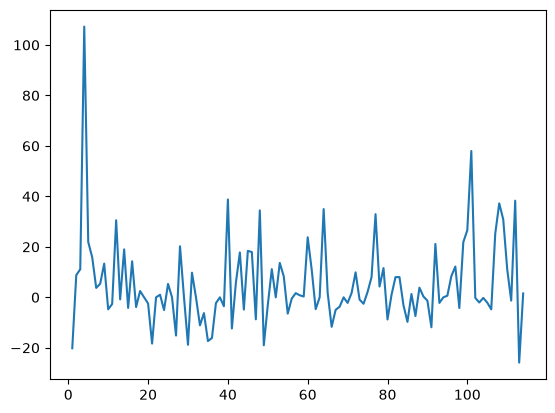

In [6]:
plt.plot(fidson_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(fidson_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-9.80666040426398), np.float64(5.801825165232643e-17), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(819.0679693327653))
stationary


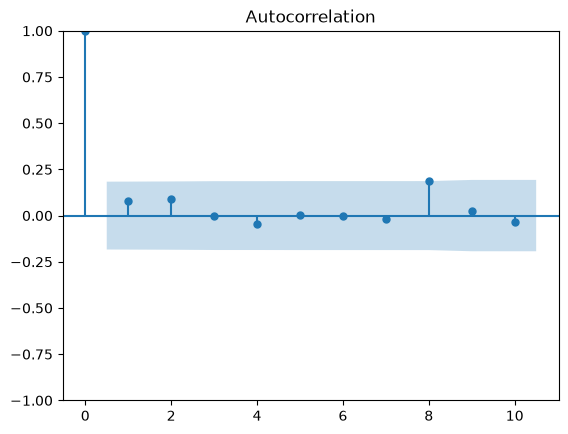

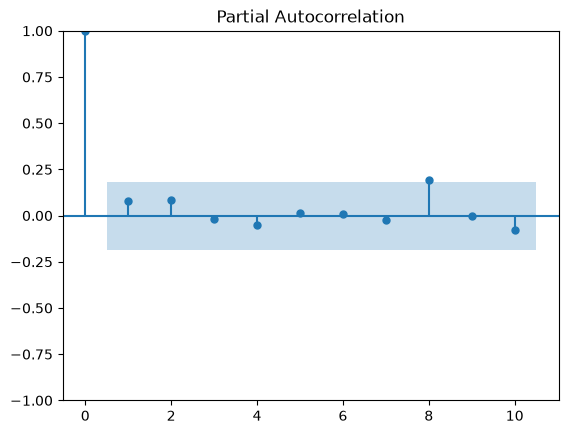

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(fidson_end_month_df['returns'].dropna(), lags=10)
plot_pacf(fidson_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=fidson_end_month_df['close_price'][:-10]
test=fidson_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -7.668490562992325]
[0, 0, 0, 0, 0, 1, -5.253520668463597]
[0, 0, 0, 0, 0, 2, -4.319436009312467]
[0, 0, 0, 0, 1, 0, -3.6095189355168893]
[0, 0, 0, 0, 1, 1, -3.475615865854091]
[0, 0, 0, 0, 1, 2, -3.9099590072000696]
[0, 0, 0, 0, 2, 0, -2.5465622309307134]
[0, 0, 0, 0, 2, 1, -2.834695893169964]
[0, 0, 0, 0, 2, 2, -2.9037488389509325]
[0, 0, 0, 1, 0, 0, -3.864889391090742]
[0, 0, 0, 1, 0, 1, -3.7960825069850044]
[0, 0, 0, 1, 0, 2, -4.151477989272405]
[0, 0, 0, 1, 1, 0, -3.3607751640265624]
[0, 0, 0, 1, 1, 1, -3.598631744741751]
[0, 0, 0, 1, 1, 2, -3.379572914887989]
[0, 0, 0, 1, 2, 0, -2.7764014040212]
[0, 0, 0, 1, 2, 1, -2.9428865933148143]
[0, 0, 0, 1, 2, 2, -3.0062272143806377]
[0, 0, 0, 2, 0, 0, -3.751634333030479]
[0, 0, 0, 2, 0, 1, -3.8775744230160383]
[0, 0, 0, 2, 0, 2, -3.794027251393258]
[0, 0, 0, 2, 1, 0, -3.27299002829153]
[0, 0, 0, 2, 1, 1, -3.351604007538258]
[0, 0, 0, 2, 1, 2, -3.419245179088315]
[0, 0, 0, 2, 2, 0, -3.0153245831692956]
[0, 0, 0, 2, 2, 1,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
372,1,1,1,2,1,0,-127.513404
0,0,0,0,0,0,0,-7.668491
27,0,0,1,0,0,0,-7.545346
54,0,0,2,0,0,0,-7.339482
55,0,0,2,0,0,1,-5.617625
...,...,...,...,...,...,...,...
196,0,2,1,0,2,1,0.007169
462,1,2,2,0,1,0,0.017410
195,0,2,1,0,2,0,0.063456
466,1,2,2,0,2,1,0.110441


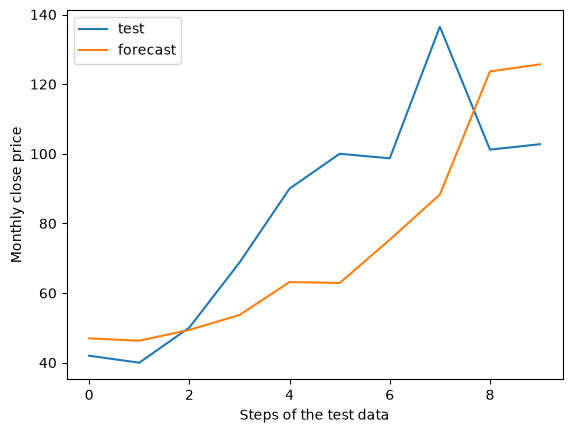

r2_score:  0.29961379344902705
rmse:  25.083719804573967
description:  count    115.000000
mean      15.797565
std       24.090881
min        0.910000
25%        4.500000
50%        6.220000
75%       15.150000
max      136.500000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=fidson_end_month_df['close_price'][:-10]
y_test=fidson_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,2), 
seasonal_order=(0,2,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', fidson_end_month_df.close_price.describe())

Its ok but the concern is the rmse is greater than the std. Thats a problem.

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=fidson_end_month_df['returns'].dropna()[:-10]
test=fidson_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.30027106811678794]
[0, 0, 0, 0, 0, 1, -0.30563767617556103]
[0, 0, 0, 0, 0, 2, -0.3768746696596992]
[0, 0, 0, 0, 1, 0, -1.4071113271653322]
[0, 0, 0, 0, 1, 1, -0.23707628247329948]
[0, 0, 0, 0, 1, 2, -0.25751730277850005]
[0, 0, 0, 0, 2, 0, -5.093606460359711]
[0, 0, 0, 0, 2, 1, -1.725717989933961]
[0, 0, 0, 0, 2, 2, -1.0331892718073976]
[0, 0, 0, 1, 0, 0, -0.3154692781315003]
[0, 0, 0, 1, 0, 1, -0.0911001078861069]
[0, 0, 0, 1, 0, 2, -0.17442672445754193]
[0, 0, 0, 1, 1, 0, -0.5655911589533971]
[0, 0, 0, 1, 1, 1, -0.20876547140722268]
[0, 0, 0, 1, 1, 2, -0.26238447512284013]
[0, 0, 0, 1, 2, 0, -1.6936368214371034]
[0, 0, 0, 1, 2, 1, -1.0194585519589179]
[0, 0, 0, 1, 2, 2, -1.0157519625822404]
[0, 0, 0, 2, 0, 0, -0.31988219756342096]
[0, 0, 0, 2, 0, 1, -0.11410905931318216]
[0, 0, 0, 2, 0, 2, -0.09585972681763621]
[0, 0, 0, 2, 1, 0, -0.5795601312790224]
[0, 0, 0, 2, 1, 1, -0.3554895546606627]
[0, 0, 0, 2, 1, 2, -0.3312551967993498]
[0, 0, 0, 2, 2, 0, -2.1062825181

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-745.634567
654,2,2,0,0,2,0,-165.835014
411,1,2,0,0,2,0,-161.807465
177,0,2,0,1,2,0,-152.078908
169,0,2,0,0,2,1,-140.857801
...,...,...,...,...,...,...,...
127,0,1,1,2,0,1,0.012597
235,0,2,2,2,0,1,0.020172
478,1,2,2,2,0,1,0.025806
397,1,1,2,2,0,1,0.029209


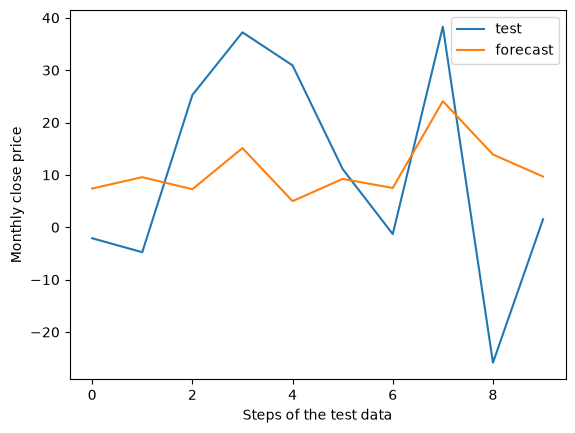

r2_score:  0.0845513786730352
rmse:  19.259898300923005
description:  count    114.000000
mean       5.200936
std       17.113039
min      -25.860806
25%       -3.443195
50%        0.329076
75%       11.111111
max      107.272727
Name: returns, dtype: float64


In [15]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=fidson_end_month_df['returns'].dropna()[:-10]
y_test=fidson_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(2,0,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', fidson_end_month_df.returns.dropna().describe())

Very horrible. rmse is still greater than the std
